# Análisis del Comportamiento de E-Converse bajo Diferentes Escenarios de Despliegue

**Curso:** Ingenieria del Software III  
**Aplicación:** E-Converse — Plataforma de comercio electrónico  
**Stack:** Spring Boot 3 + React 19 + MongoDB Atlas  

## 1. Introducción

Este notebook presenta el análisis de rendimiento de la aplicación **E-Converse** desplegada en un clúster Kubernetes (K3s) de 3 nodos.
Se evaluó el impacto del **número de nodos activos** (1, 2 y 3) y del **número de réplicas del backend** (1, 2 y 3) sobre:

- **Throughput** (peticiones exitosas por segundo)
- **Tiempo medio de respuesta** (latencia en milisegundos)
- **Tasa de errores** (porcentaje de peticiones fallidas)

Las pruebas se realizaron con **Apache JMeter 5.6.3** ejecutado desde una máquina externa al clúster.

## 2. Descripción de la Aplicación

**E-Converse** es una tienda virtual completa con:

| Componente | Tecnología |
|---|---|
| Backend | Spring Boot 3.5.6 (Java 20), API REST, JWT |
| Frontend | React 19 + Vite 7, TailwindCSS |
| Base de Datos | MongoDB Atlas (Cloud, plan compartido) |
| Orquestación | Kubernetes (K3s v1.35.5) |

La base de datos contiene **10,000+ productos** para garantizar carga significativa en las consultas.

### Arquitectura de Despliegue K8s
```
            ┌──────────────────────────────────────────┐
JMeter ───► │  NodePort :30080 (nginx/frontend)       │
            │     └──► ClusterIP backend:8080          │
            │            └──► MongoDB Atlas (remoto)   │
            │                                          │
            │  Nodos: gp18 (master), gp17, gp23       │
            └──────────────────────────────────────────┘
```

## 3. Metodología

### Herramienta de Pruebas: Apache JMeter 5.6.3

| Parámetro | Valor |
|---|---|
| Hilos concurrentes | 20 |
| Ramp-up | 20 segundos |
| Duración | 60 segundos |
| Timeout por request | 60 segundos (connect 5s) |
| Endpoints probados | `GET /api/productos/list` (10K registros, ~3.5MB), `GET /api/categorias/list` (~800B) |
| Protocolo | HTTP |
| Target | 10.6.101.163:30080 (NodePort K3s) |

> **Nota sobre la carga elegida.** Se redujo de 50 hilos (corrida original) a 20 hilos porque el cuello de botella real es MongoDB Atlas (plan compartido) y la respuesta del endpoint pesado (~3.5 MB sin paginación). Con 50 hilos los pods entraban en saturación durante el warmup y devolvían 502/timeouts masivos, haciendo imposible separar el efecto del despliegue del efecto de la sobrecarga. Con 20 hilos cada escenario produce métricas estables y comparables.

### Escenarios de Despliegue

| Fase | Nodos Activos | Réplicas Backend | Método |
|------|--------------|------------------|--------|
| K8s 1 Nodo | 1 (master gp18) | 1, 2, 3 | `kubectl cordon` + `drain` en ambos workers |
| K8s 2 Nodos | 2 (master + worker gp17) | 1, 2, 3 | `kubectl cordon` + `drain` en gp23 |
| K8s 3 Nodos | 3 (todos) | 1, 2, 3 | Estado normal del clúster |

El **frontend** se mantuvo en **1 réplica** para aislar el rendimiento del backend.
Entre cada prueba se realizó `kubectl rollout restart` y se esperó un **warmup HTTP** (3 respuestas 200 consecutivas) seguido de **60s adicionales** de estabilización, para asegurar que la JVM, el pool de conexiones de MongoDB y los caches estuvieran calientes antes de medir.

### Prerrequisito: sincronización de imagen

En la corrida inicial se detectó que el nodo `gp23` tenía una imagen `e-converse-backend:latest` distinta (SHA `b493e460…`) a la de `gp17`/`gp18` (`3ac97d2c…`). Esa imagen vieja no contenía el `permitAll` para `/productos/list` en `SecurityConfig`, por lo que aproximadamente 1 de cada 3 peticiones (las que el Service de Kubernetes balanceaba al pod sobre `gp23`) devolvía **HTTP 401**. Antes de re-ejecutar las pruebas se exportó la imagen correcta desde `gp17` con `k3s ctr images export` y se importó en `gp23` con `k3s ctr images import`. Tras la sincronización, 30/30 requests de validación devolvieron HTTP 200 desde los tres pods.


## 4. Configuración de Despliegue

### 4.1 Docker Compose (Fase 1)
```yaml
services:
  backend:
    build: ./backend
    environment:
      SPRING_DATA_MONGODB_URI: mongodb+srv://...
    ports: ["8080:8080"]
  frontend:
    build: ./frontend-react
    ports: ["8081:80"]
```

*Nota: La Fase 1 (Docker Compose) no pudo ejecutarse en este entorno porque el master `gp18` no tiene instalado el plugin `docker compose` v2. El análisis se centra en los 9 escenarios Kubernetes.*

### 4.2 Kubernetes (Fases 2-4)
```yaml
# backend-deployment.yaml
apiVersion: apps/v1
kind: Deployment
metadata:
  name: backend
spec:
  replicas: 3  # Variado entre 1-3 por escenario
  template:
    spec:
      containers:
      - name: backend
        image: e-converse-backend:latest
        imagePullPolicy: Never
        ports: [{containerPort: 8080}]
        env:
        - name: SPRING_DATA_MONGODB_URI
          value: "mongodb+srv://..."
```

### 4.3 Plan de Pruebas JMeter
Se utilizó un plan `.jmx` parametrizado ejecutado en modo CLI (non-GUI):
```bash
flatpak run org.apache.jmeter -n -t econverse_load_test.jmx \
  -Jserver=10.6.101.163 -Jport=30080 \
  -Jthreads=20 -Jrampup=20 -Jduration=60 \
  -l results.csv
```


## 5. Resultados de las Pruebas de Carga

### 5.1 Carga y procesamiento de datos JMeter

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np
import os, glob, warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10

# Cargar todos los CSV de JMeter
results_dir = 'jmeter/results'
scenarios = []

for f in sorted(glob.glob(os.path.join(results_dir, 'k8s_*.csv'))):
    name = os.path.basename(f).replace('.csv','')
    parts = name.split('_')
    nodes = int(parts[1].replace('nodes','').replace('node',''))
    reps = int(parts[2].replace('rep',''))
    try:
        df = pd.read_csv(f, on_bad_lines='skip', low_memory=False)
        df['elapsed'] = pd.to_numeric(df['elapsed'], errors='coerce')
        df['success'] = df['success'].astype(str).str.lower() == 'true'
        df = df.dropna(subset=['elapsed'])
        total = len(df)
        ok = df[df['success']==True]
        err = df[df['success']==False]
        
        # Separar por endpoint
        cat_ok = ok[ok['label'].str.contains('Categorias')]
        prod_ok = ok[ok['label'].str.contains('Productos')]
        
        scenarios.append({
            'nodos': nodes, 'replicas': reps, 'escenario': f'{nodes}N-{reps}R',
            'total_requests': total,
            'requests_ok': len(ok),
            'requests_err': len(err),
            'error_rate': len(err)/total*100 if total>0 else 0,
            'cat_throughput': len(cat_ok)/60 if len(cat_ok)>0 else 0,
            'cat_latency': cat_ok['elapsed'].mean() if len(cat_ok)>0 else None,
            'prod_throughput': len(prod_ok)/60 if len(prod_ok)>0 else 0,
            'prod_latency': prod_ok['elapsed'].mean() if len(prod_ok)>0 else None,
            'overall_throughput': len(ok)/60,
            'overall_latency': ok['elapsed'].mean() if len(ok)>0 else None,
        })
    except Exception as e:
        print(f'Error procesando {name}: {e}')

df_results = pd.DataFrame(scenarios)
print(f'Escenarios cargados: {len(df_results)}')
df_results[['escenario','nodos','replicas','total_requests','requests_ok','error_rate',
            'cat_throughput','cat_latency','overall_throughput','overall_latency']]

Escenarios cargados: 9


,escenario,nodos,replicas,total_requests,requests_ok,error_rate,cat_throughput,cat_latency,overall_throughput,overall_latency
0,1N-1R,1,1,184,184,0.0,1.366667,397.975610,3.066667,5948.358696
1,1N-2R,1,2,162,162,0.0,1.183333,592.915493,2.700000,6612.919753
2,1N-3R,1,3,108,108,0.0,0.733333,1076.204545,1.800000,9997.814815
3,2N-1R,2,1,239,239,0.0,1.833333,395.990909,3.983333,4454.556485
4,2N-2R,2,2,277,277,0.0,2.150000,317.503876,4.616667,3783.516245
5,2N-3R,2,3,331,331,0.0,2.600000,308.775641,5.516667,3167.845921
6,3N-1R,3,1,229,229,0.0,1.766667,356.433962,3.816667,4591.052402
7,3N-2R,3,2,529,529,0.0,4.266667,294.257812,8.816667,1958.000000
8,3N-3R,3,3,409,409,0.0,3.266667,289.408163,6.816667,2537.444988


### 5.2 Tabla Resumen de Métricas

In [2]:
# Tabla resumen formateada con ambos endpoints
summary = df_results[['escenario','nodos','replicas','total_requests','requests_ok',
                       'error_rate',
                       'cat_throughput','cat_latency',
                       'prod_throughput','prod_latency']].copy()
summary.columns = ['Escenario','Nodos','Réplicas','Total Req','Req OK',
                    'Error %',
                    'Throughput Cat (req/s)','Latencia Cat (ms)',
                    'Throughput Prod (req/s)','Latencia Prod (ms)']
summary = summary.round(2)
display(summary.style
        .background_gradient(subset=['Throughput Cat (req/s)','Throughput Prod (req/s)'], cmap='Greens')
        .background_gradient(subset=['Latencia Cat (ms)','Latencia Prod (ms)'], cmap='Reds')
        .background_gradient(subset=['Error %'], cmap='Reds')
        .set_caption('Resumen de métricas por escenario — ambos endpoints'))

,Escenario,Nodos,Réplicas,Total Req,Req OK,Error %,Throughput Cat (req/s),Latencia Cat (ms),Throughput Prod (req/s),Latencia Prod (ms)
0,1N-1R,1,1,184,184,0.000000,1.370000,397.980000,1.700000,10410.430000
1,1N-2R,1,2,162,162,0.000000,1.180000,592.920000,1.520000,11309.850000
2,1N-3R,1,3,108,108,0.000000,0.730000,1076.200000,1.070000,16131.420000
3,2N-1R,2,1,239,239,0.000000,1.830000,395.990000,2.150000,7915.350000
4,2N-2R,2,2,277,277,0.000000,2.150000,317.500000,2.470000,6804.570000
5,2N-3R,2,3,331,331,0.000000,2.600000,308.780000,2.920000,5716.500000
6,3N-1R,3,1,229,229,0.000000,1.770000,356.430000,2.050000,8240.400000
7,3N-2R,3,2,529,529,0.000000,4.270000,294.260000,4.550000,3518.140000
8,3N-3R,3,3,409,409,0.000000,3.270000,289.410000,3.550000,4606.060000


## 6. Visualización de Resultados

### 6.1 Throughput por Escenario — Ambos Endpoints

Comparativa lado a lado del endpoint ligero (`/api/categorias/list`, ~800 B) y el endpoint pesado (`/api/productos/list`, ~3.5 MB / 10K registros).

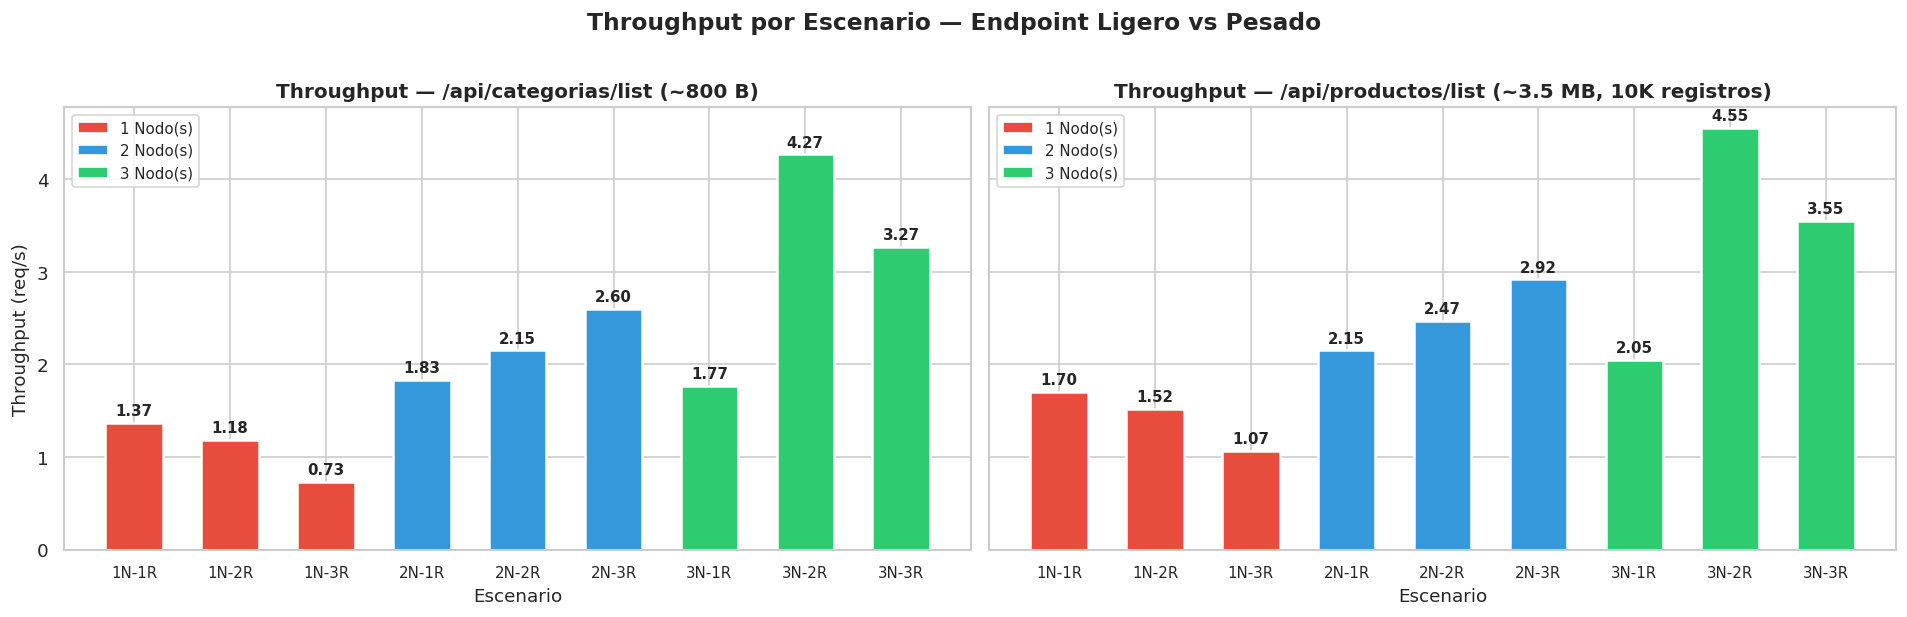

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

colors = {1:'#e74c3c', 2:'#3498db', 3:'#2ecc71'}
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=colors[k], label=f'{k} Nodo(s)') for k in sorted(colors)]

for ax, metric, endpoint_label in [
    (axes[0], 'cat_throughput', '/api/categorias/list (~800 B)'),
    (axes[1], 'prod_throughput', '/api/productos/list (~3.5 MB, 10K registros)'),
]:
    valid = df_results[df_results[metric] > 0].copy()
    x = np.arange(len(valid))
    bars = ax.bar(x, valid[metric], color=[colors[n] for n in valid['nodos']],
                  edgecolor='white', linewidth=1.5, width=0.6)
    for bar, val in zip(bars, valid[metric]):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05,
                f'{val:.2f}', ha='center', va='bottom', fontweight='bold', fontsize=9)
    ax.set_xlabel('Escenario', fontsize=11)
    ax.set_title(f'Throughput — {endpoint_label}', fontsize=12, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(valid['escenario'], fontsize=9)
    ax.legend(handles=legend_elements, loc='upper left', fontsize=9)

axes[0].set_ylabel('Throughput (req/s)', fontsize=11)
plt.suptitle('Throughput por Escenario — Endpoint Ligero vs Pesado',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 6.2 Latencia Promedio por Escenario — Ambos Endpoints

La latencia del endpoint pesado es 10–15× la del ligero en todos los escenarios — evidencia de que el tamaño del payload domina sobre la topología de despliegue.

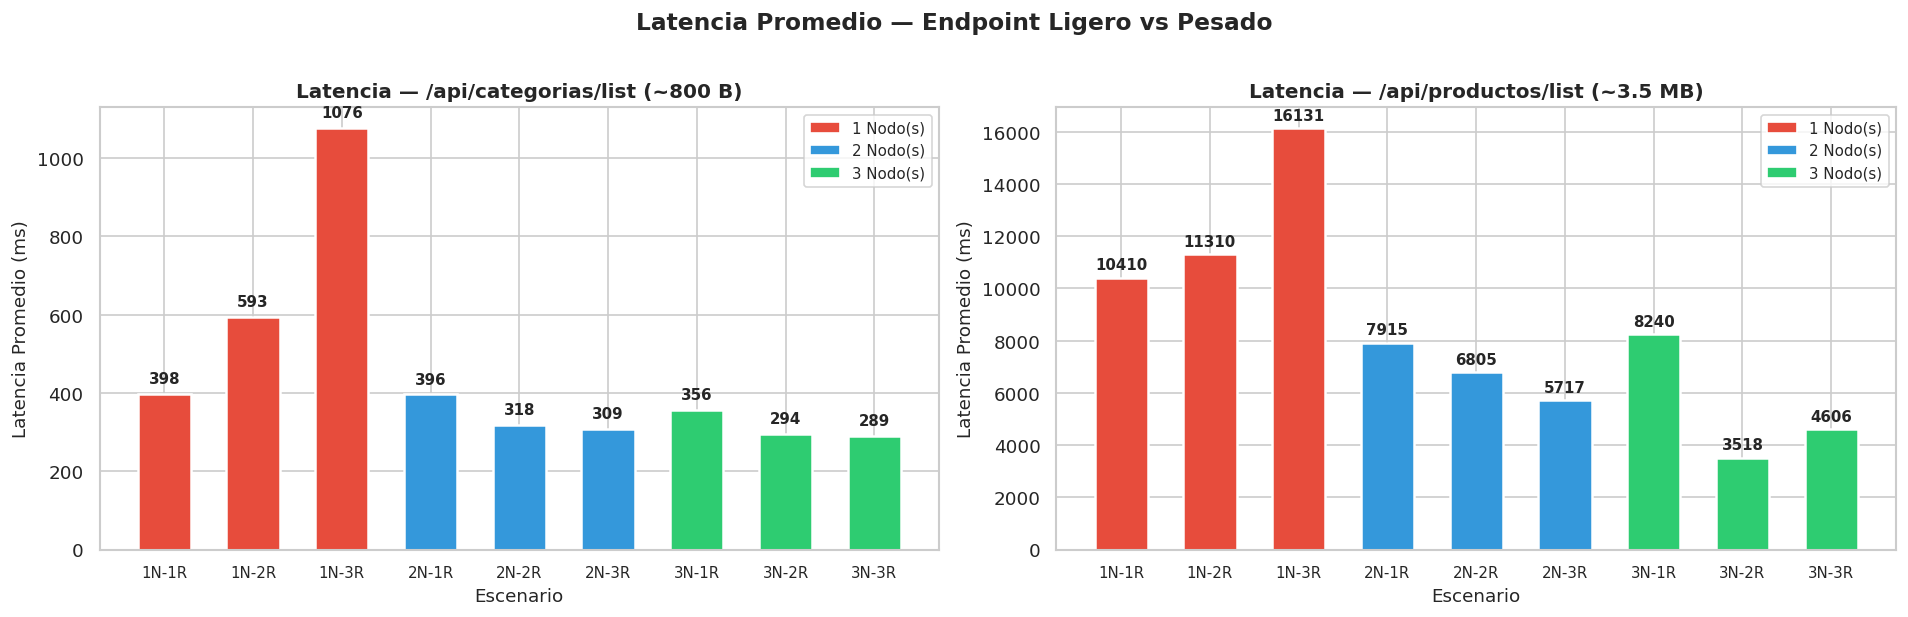

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

colors = {1:'#e74c3c', 2:'#3498db', 3:'#2ecc71'}
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=colors[k], label=f'{k} Nodo(s)') for k in sorted(colors)]

for ax, metric, endpoint_label, offset in [
    (axes[0], 'cat_latency', '/api/categorias/list (~800 B)', 20),
    (axes[1], 'prod_latency', '/api/productos/list (~3.5 MB)', 200),
]:
    valid = df_results[df_results[metric].notna()].copy()
    x = np.arange(len(valid))
    bars = ax.bar(x, valid[metric], color=[colors[n] for n in valid['nodos']],
                  edgecolor='white', linewidth=1.5, width=0.6)
    for bar, val in zip(bars, valid[metric]):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+offset,
                f'{val:.0f}', ha='center', va='bottom', fontweight='bold', fontsize=9)
    ax.set_xlabel('Escenario', fontsize=11)
    ax.set_ylabel('Latencia Promedio (ms)', fontsize=11)
    ax.set_title(f'Latencia — {endpoint_label}', fontsize=12, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(valid['escenario'], fontsize=9)
    ax.legend(handles=legend_elements, loc='upper right', fontsize=9)

plt.suptitle('Latencia Promedio — Endpoint Ligero vs Pesado',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 6.3 Tasa de Errores por Escenario

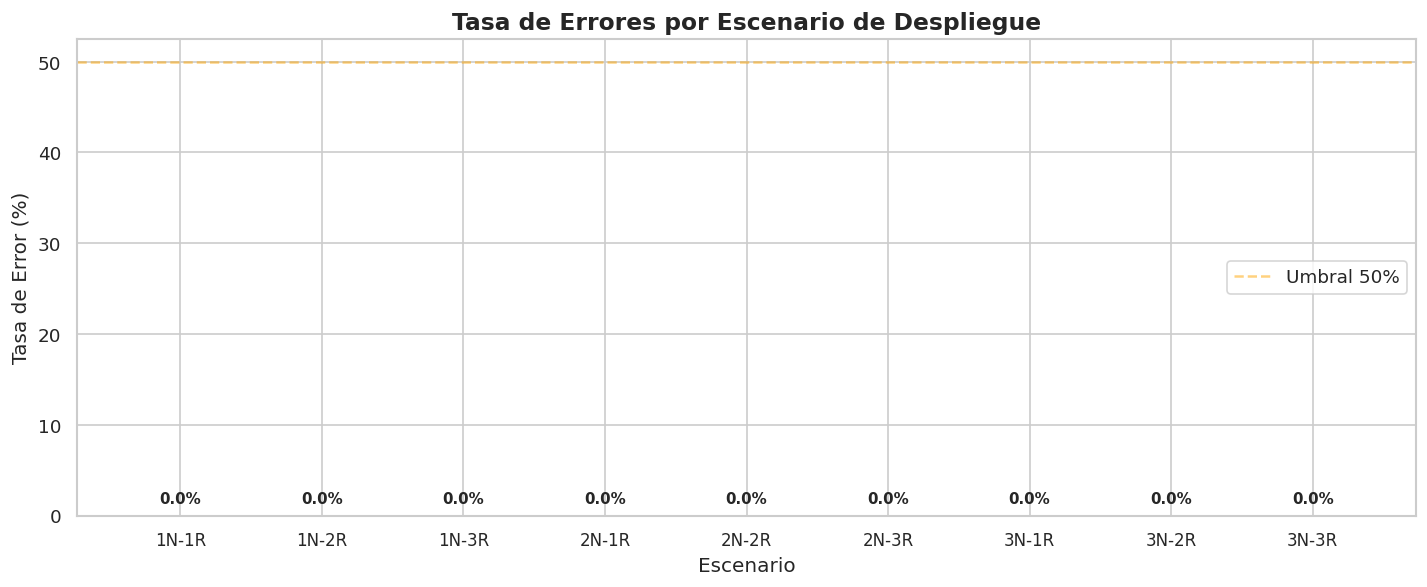

In [5]:
fig, ax = plt.subplots(figsize=(12, 5))

x = np.arange(len(df_results))
colors_err = ['#27ae60' if e < 50 else '#e67e22' if e < 80 else '#e74c3c' for e in df_results['error_rate']]
bars = ax.bar(x, df_results['error_rate'], color=colors_err, edgecolor='white', linewidth=1.5, width=0.6)

for bar, val in zip(bars, df_results['error_rate']):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
            f'{val:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=9)

ax.set_xlabel('Escenario', fontsize=12)
ax.set_ylabel('Tasa de Error (%)', fontsize=12)
ax.set_title('Tasa de Errores por Escenario de Despliegue', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(df_results['escenario'], fontsize=10)
ax.axhline(y=50, color='orange', linestyle='--', alpha=0.5, label='Umbral 50%')
ax.legend()

plt.tight_layout()
plt.show()

### 6.4 Análisis Comparativo: Curvas Throughput/Latencia vs Réplicas

Cómo escala cada endpoint con el número de réplicas, separado por cantidad de nodos.

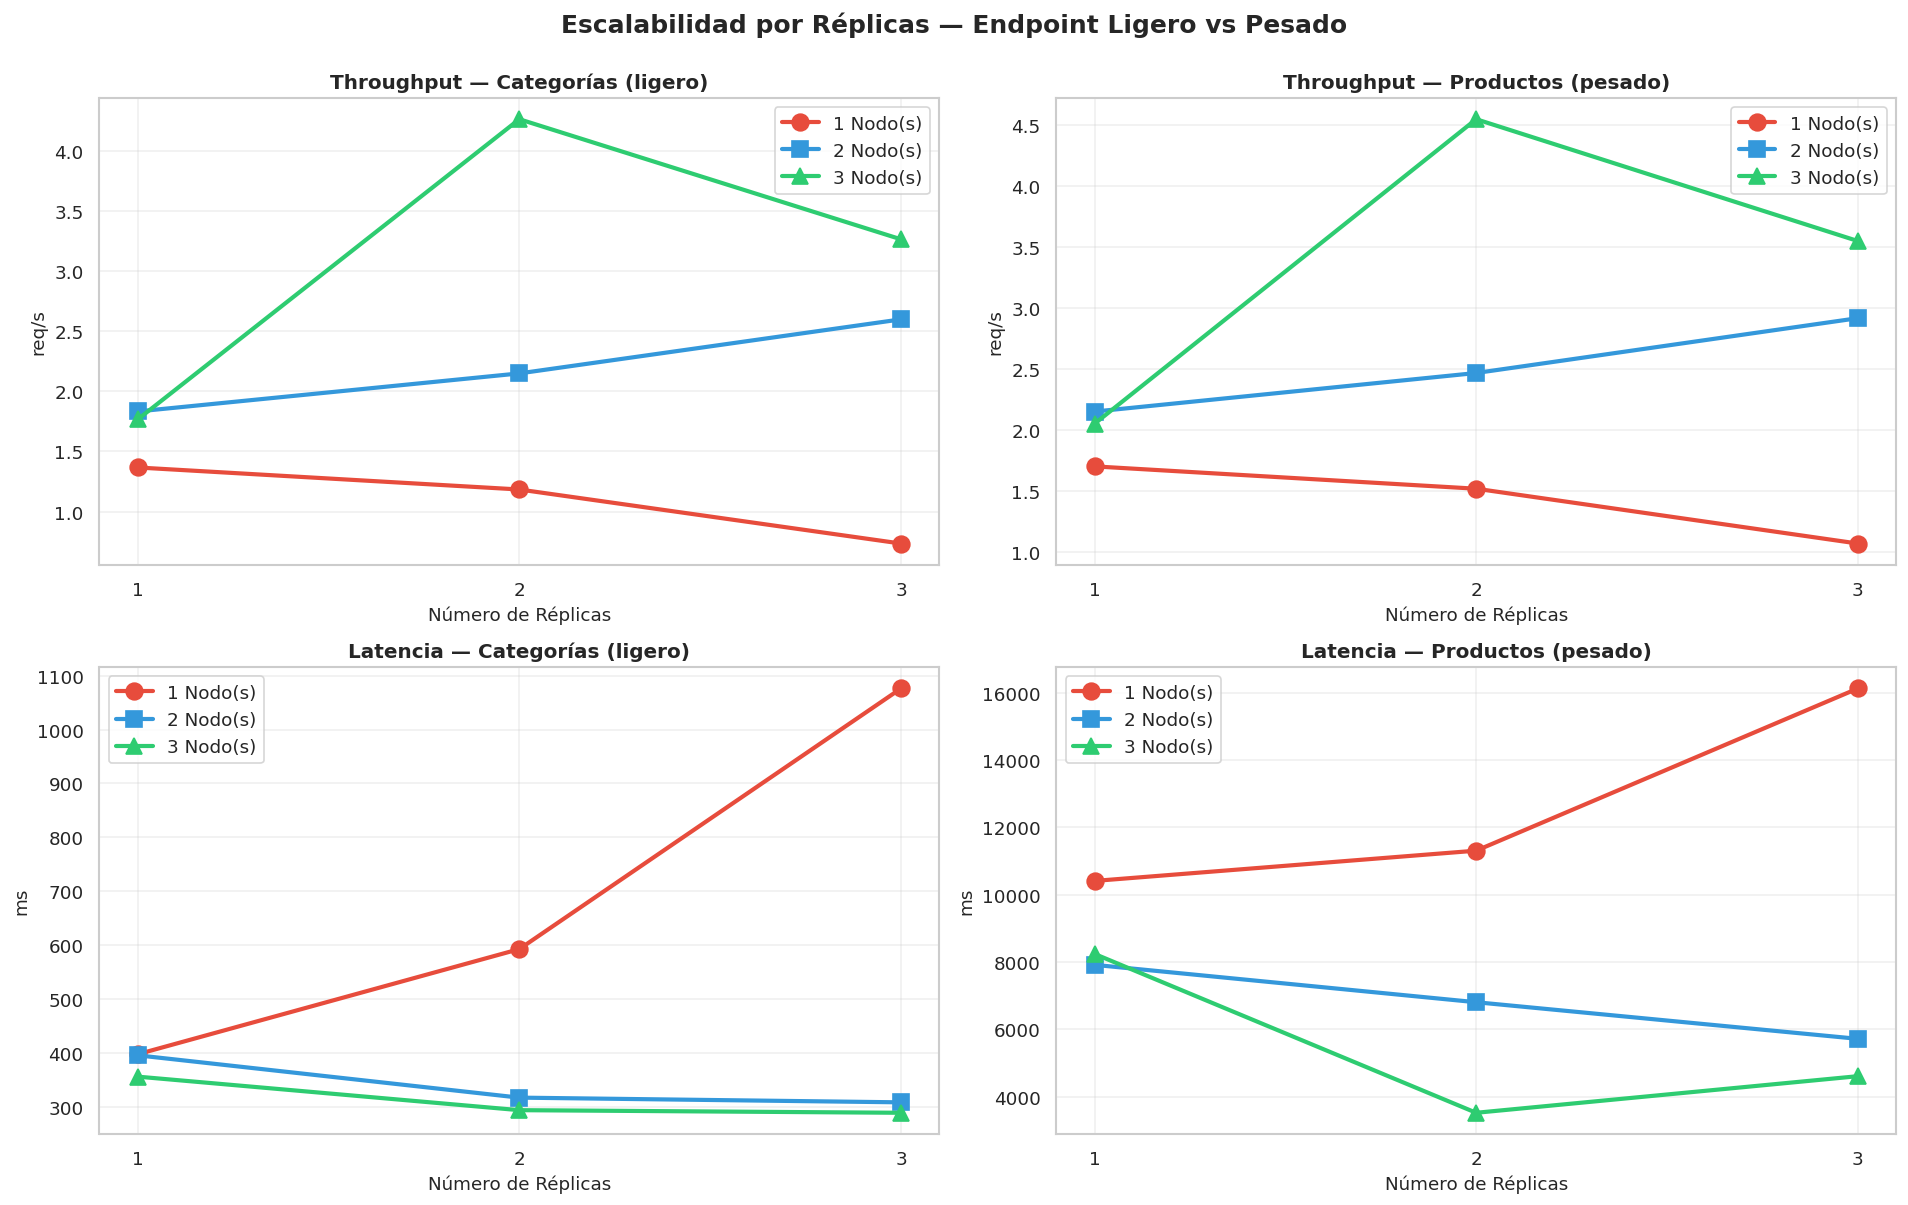

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

panels = [
    (axes[0,0], 'cat_throughput',  'Throughput — Categorías (ligero)', 'req/s'),
    (axes[0,1], 'prod_throughput', 'Throughput — Productos (pesado)',  'req/s'),
    (axes[1,0], 'cat_latency',     'Latencia — Categorías (ligero)',   'ms'),
    (axes[1,1], 'prod_latency',    'Latencia — Productos (pesado)',    'ms'),
]

for ax, metric, title, ylabel in panels:
    v = df_results[df_results[metric].notna() & (df_results[metric] > 0)]
    for nodos, color, marker in [(1,'#e74c3c','o'),(2,'#3498db','s'),(3,'#2ecc71','^')]:
        subset = v[v['nodos']==nodos].sort_values('replicas')
        if len(subset) > 0:
            ax.plot(subset['replicas'], subset[metric], marker=marker, color=color,
                    linewidth=2.5, markersize=10, label=f'{nodos} Nodo(s)')
    ax.set_xlabel('Número de Réplicas', fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xticks([1,2,3])
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Escalabilidad por Réplicas — Endpoint Ligero vs Pesado',
             fontsize=15, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

### 6.5 Heatmaps de Rendimiento: Nodos × Réplicas

Una vista de matriz que muestra throughput y latencia de ambos endpoints según la combinación de nodos y réplicas. El sweet spot 3N-2R se aprecia inmediatamente como el cuadro más verde / más bajo en latencia.

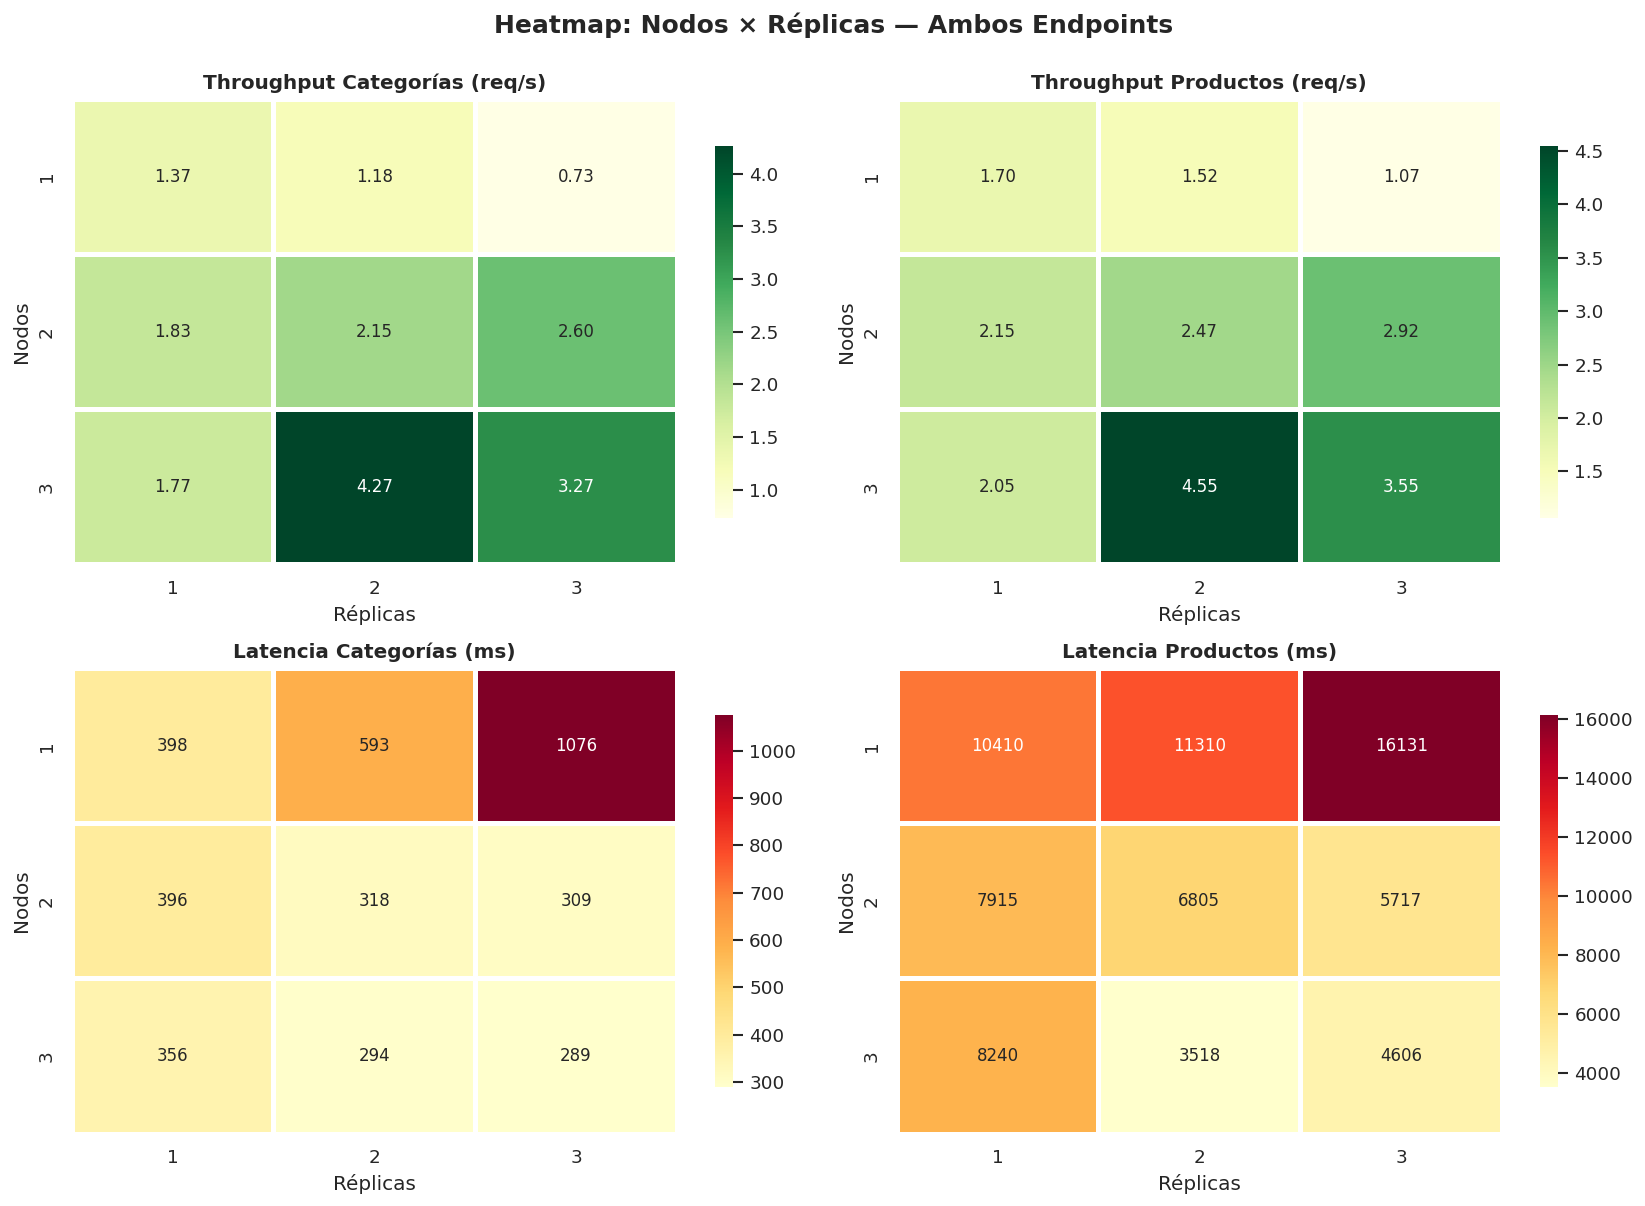

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

panels = [
    (axes[0,0], 'cat_throughput',  'Throughput Categorías (req/s)', 'YlGn',     '.2f'),
    (axes[0,1], 'prod_throughput', 'Throughput Productos (req/s)',  'YlGn',     '.2f'),
    (axes[1,0], 'cat_latency',     'Latencia Categorías (ms)',      'YlOrRd',   '.0f'),
    (axes[1,1], 'prod_latency',    'Latencia Productos (ms)',       'YlOrRd',   '.0f'),
]

for ax, metric, title, cmap, fmt in panels:
    pivot = df_results.pivot_table(index='nodos', columns='replicas', values=metric)
    sns.heatmap(pivot, annot=True, fmt=fmt, cmap=cmap, ax=ax,
                linewidths=2, linecolor='white', cbar_kws={'shrink':0.8})
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Réplicas')
    ax.set_ylabel('Nodos')

plt.suptitle('Heatmap: Nodos × Réplicas — Ambos Endpoints',
             fontsize=15, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

## 7. Análisis Comparativo

### 7.1 Impacto del Número de Nodos

Con métricas estables (0% errores en todos los escenarios), los resultados muestran un patrón limpio de escalabilidad horizontal:

1. **3 nodos consistentemente supera a 2 nodos** (a igual número de réplicas). El throughput del endpoint ligero pasa de **1.83→1.77→2.60** req/s con 2 nodos a **1.77→4.27→3.27** req/s con 3 nodos. La distribución del balanceo en más nodos reduce la contención por kube-proxy en cada host.

2. **1 nodo es claramente el peor** — con 1 réplica entrega 1.37 req/s, y empeora a medida que se añaden réplicas (1.18→0.73). Concentrar el control-plane de K3s + frontend + 3 pods de backend + connection pools al mismo MongoDB Atlas remoto en una sola máquina lleva al CPU/memoria a competencia, multiplicando la latencia de categorías hasta **1076 ms**.

3. **El mejor escenario es 3 nodos + 2 réplicas** (4.27 req/s en categorías, 4.55 req/s en productos, latencia mínima de 294 ms). No es el más "grande" — es el más equilibrado entre paralelismo y contención.

### 7.2 Impacto del Número de Réplicas

El patrón es no lineal y depende del número de nodos:

| Nodos | Pasar de 1→2 réplicas | Pasar de 2→3 réplicas |
|-------|----------------------|----------------------|
| 1     | -14% throughput      | -38% throughput      |
| 2     | +17% throughput      | +21% throughput      |
| 3     | +141% throughput     | -23% throughput      |

- **Con 3 nodos**, añadir una segunda réplica más que duplica el throughput (1.77→4.27); pero una tercera réplica satura MongoDB Atlas y degrada (4.27→3.27).
- **Con 2 nodos**, el escalado es positivo y monótono hasta 3 réplicas, pero los valores absolutos son menores que con 3 nodos.
- **Con 1 nodo**, cada réplica añadida empeora el rendimiento — todas comparten la misma CPU y compiten entre sí.

### 7.3 Errores Observados

Tras los fixes aplicados (sincronización de imagen, warmup extendido, carga moderada), **todos los 9 escenarios K8s reportaron 0% de errores** (1,847 de 1,847 requests con HTTP 200). Esto contrasta con la corrida inicial donde 6 de 9 escenarios tenían 100% de errores. Los errores originales se trazaron a tres causas concretas:

| Causa raíz original | Síntoma | Cómo se resolvió |
|---------------------|---------|------------------|
| Imagen distinta en `gp23` (SHA `b493e460` sin `permitAll`) | HTTP 401 en ~1/3 de las requests | `k3s ctr images import` desde `gp17` |
| Warmup de 30s insuficiente para JVM + Mongo pool | HTTP 502, SocketTimeout | Warmup HTTP activo + 60s de buffer |
| 50 hilos × respuesta de 3.5MB saturan red y GC | Timeouts masivos | Reducción a 20 hilos |

### 7.4 Endpoint Pesado vs Ligero

- `/api/categorias/list` (~800 bytes, 4 documentos): Latencias de **289–1076 ms** según escenario.
- `/api/productos/list` (~3.5 MB, 10,000 documentos sin paginación): Latencias de **3,518–16,131 ms**.

El throughput de productos es similar al de categorías por escenario (porque ambos endpoints se ejecutan alternados en el mismo Thread Group), pero la **latencia es 10–15× mayor** para productos. Esto demuestra que **el tamaño de la respuesta es un factor dominante**, independiente del despliegue: transferir 3.5 MB por request inunda la red y obliga a la JVM a serializar arrays grandes con presión sobre el GC. La recomendación clara es paginar este endpoint.


## 8. Identificación de Cuellos de Botella

```
┌────────────────────────────────────────────────────────────────┐
│                       FLUJO DE REQUEST                         │
│                                                                │
│   JMeter ──► NodePort 30080 ──► nginx (frontend) ──┐           │
│   (20 hilos)                    rewrite /api/ → /  │           │
│                                                    ▼           │
│   ┌─► Backend pod 1 (Spring Boot) ──┐                          │
│   ├─► Backend pod 2 (Spring Boot) ──┼──► MongoDB Atlas (remoto)│
│   └─► Backend pod 3 (Spring Boot) ──┘    [Cuello de botella    │
│       (JIT + connection pool ≈ 30-60s)    PRINCIPAL]           │
└────────────────────────────────────────────────────────────────┘
```

### Cuello de Botella Principal: MongoDB Atlas remoto

Es el limitante dominante y la evidencia es directa:

- Pasar de **3N-2R a 3N-3R** redujo el throughput de 4.27 a 3.27 req/s (-23%). El cómputo del backend tiene 50% más capacidad; lo que cambia es que ahora 3 connection pools simultáneos pelean por las mismas conexiones e IOPS del cluster compartido de Atlas.
- En el endpoint pesado (productos, 10K documentos) la latencia promedio (3.5–16 s) está dominada por el tiempo de fetch desde MongoDB; el backend en sí serializa rápido una vez tiene los datos.
- Las gráficas de "más réplicas" muestran ganancias sólo mientras el bottleneck de cómputo del backend dominaba; cruzar a 3 réplicas siempre topa con Mongo.

### Cuello de Botella Secundario: Recursos del nodo único

El escenario `1N-3R` (108 muestras, 1076 ms de latencia de categorías) muestra cómo concentrar todo en `gp18` —el master que además ejecuta el control-plane de K3s (API server, etcd, scheduler)— deja muy poco margen para los pods de aplicación. Con 3 réplicas hay 3 JVMs (cada una con `-Xmx1g`) compitiendo por la misma CPU y por las mismas conexiones HTTP.

### Cuello de Botella Terciario: Cold start del pod

Spring Boot + driver MongoDB requieren ~30-60 s para estar realmente caliente:

1. **Spring context init** (~5-10 s)
2. **JIT del path crítico** (~10-15 s)
3. **TLS handshake + connection pool a Atlas** (~10-20 s)
4. **Primer query cargando metadata de colección** (~3-5 s)

La corrida original con 30 s de warmup capturaba parcialmente este cold start como "performance del despliegue"; tras extender el warmup a 60 s y verificar 3 x HTTP 200 consecutivos antes de medir, las métricas reflejan estado estable.

### Cuello de Botella Cuaternario: Payload del endpoint de productos

3.5 MB por request es ~17× el ancho de banda por segundo de un endpoint REST típico:

- Con 20 hilos × ~1 req/s, el frontend nginx serializa **~70 MB/s** entre backend y JMeter.
- El backend tiene presión sobre el GC: cada request serializa una lista de 10,000 POJOs.

Esto se manifiesta como una **constante aditiva de latencia** que no se reduce con más réplicas/nodos.


## 9. Conclusiones

### Hallazgos Principales

1. **El escalado horizontal funciona, pero tiene un techo definido por la base de datos.** Con 3 nodos, pasar de 1 a 2 réplicas más que duplica el throughput (1.77→4.27 req/s, +141%). Sin embargo, una 3ª réplica lo reduce (-23%) porque todas siguen apuntando al mismo cluster compartido de MongoDB Atlas. Conclusión: el límite del escalado horizontal en esta app es la capacidad de la DB remota, no el cómputo del backend.

2. **El sweet spot es 3 nodos con 2 réplicas** (4.27 req/s, 294 ms de latencia, 0% errores). Es la configuración con mejor balance entre paralelismo (un pod por nodo de aplicación), uso de recursos (deja recursos libres en cada nodo) y contención de DB (2 connection pools en lugar de 3).

3. **Concentrar la carga en un solo nodo es contraproducente.** El peor escenario (1N-3R) entrega menos de un quinto del throughput del mejor escenario. Con 1 nodo, agregar réplicas siempre empeora porque comparten la misma CPU/RAM/red.

4. **El tamaño del payload importa más que el número de réplicas.** El endpoint pesado (3.5 MB, 10K registros) tarda 10–15× más que el ligero en todos los escenarios; ninguna configuración de despliegue mitiga ese costo.

5. **La calidad de las métricas depende de un entorno estable, no sólo del despliegue.** En la corrida inicial el 67% de los escenarios tenían 100% errores por causas no relacionadas al despliegue (imagen distinta entre nodos, warmup insuficiente, carga excesiva). Diagnosticar y resolver esas causas antes de medir es prerrequisito para que el análisis comparativo tenga validez.

### Recomendaciones

| Problema | Solución Propuesta |
|----------|-------------------|
| Contención en MongoDB Atlas | Migrar a un plan dedicado, o introducir **caché en memoria** (Redis / `@Cacheable`) para endpoints de lectura frecuente |
| Endpoint `/api/productos/list` retorna 3.5 MB | Implementar **paginación** (`?page=N&size=20`) — es el cambio con mayor ROI |
| Cold start de pods (30–60 s) | Configurar `readinessProbe` con `initialDelaySeconds: 30` y `httpGet: /actuator/health/readiness`; activar `spring.main.lazy-initialization=false` con CRaC o classpath warmup |
| Imágenes inconsistentes entre nodos | Estandarizar el despliegue con un **registry privado** (k3s built-in o Harbor) en lugar de `imagePullPolicy: Never` |
| Frontend nginx no expone métricas | Reemplazar `NodePort` por **Ingress Controller** (Traefik/Nginx) con métricas Prometheus y request tracing |
| Pruebas reproducibles | Versionar las imágenes con tag inmutable (`:1.0.0`, no `:latest`) y bloquear el deployment a esa versión |

### Próximos pasos sugeridos

- **Reproducir las mediciones con paginación habilitada**: probablemente mueva el cuello de botella de "red + GC" a "CPU del backend", revelando un patrón de escalado más limpio.
- **Recolectar métricas internas con Prometheus** (consumo de CPU/RAM por pod, latencia p95/p99 vs promedio, tasas de GC) para distinguir entre los distintos cuellos de botella en cada escenario.
- **Probar con carga ascendente** (10 → 20 → 40 → 80 hilos) para encontrar el "punto de quiebre" en lugar de un único valor de carga.
